<a href="https://colab.research.google.com/github/missliuallison-bit/git-tutorial/blob/main/Pandas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 看資料的常用指令
print("前 3 列：")
print(df.head())          # 看前幾列 (預設 5)

print("\n這張表有幾列幾欄:", df.shape)   # (列數, 欄數)

print("\n所有欄位名稱:", list(df.columns))

In [1]:
import pandas as pd

# 準備一組 YouBike 站點的假資料 (字典 → DataFrame)
data = {
    "站名":   ["大安站", "信義站", "中山站", "松山站", "大安森林", "市府站", "南港站", "內湖站"],
    "行政區": ["大安區", "信義區", "中山區", "松山區", "大安區", "信義區", "南港區", "內湖區"],
    "可借":   [12, 0, 8, 5, 20, 3, 0, 15],
    "可還":   [8, 20, 12, 15, 0, 17, 25, 5],
    "總停車格": [20, 20, 20, 20, 20, 20, 25, 20],
}

df = pd.DataFrame(data)
df

,站名,行政區,可借,可還,總停車格
0,大安站,大安區,12,8,20
1,信義站,信義區,0,20,20
2,中山站,中山區,8,12,20
3,松山站,松山區,5,15,20
4,大安森林,大安區,20,0,20
5,市府站,信義區,3,17,20
6,南港站,南港區,0,25,25
7,內湖站,內湖區,15,5,20


In [ ]:
# describe() 自動算出數字欄的：筆數、平均、最大最小、四分位數
df.describe()

In [2]:
# (1) 挑「單一欄位」→ 用中括號 + 欄名
print("所有站名：")
print(df["站名"])

所有站名：
0     大安站
1     信義站
2     中山站
3     松山站
4    大安森林
5     市府站
6     南港站
7     內湖站
Name: 站名, dtype: object


In [3]:
# (2) 挑「多個欄位」→ 中括號裡放一個清單
df[["站名", "可還"]]

,站名,可還
0,大安站,8
1,信義站,20
2,中山站,12
3,松山站,15
4,大安森林,0
5,市府站,17
6,南港站,25
7,內湖站,5


In [4]:
# (3) 挑「符合條件的列」→ 在中括號裡放條件 (這叫布林篩選)
# 例如：找出「目前沒車可借」的站點
df[df["可還"] > 5]

,站名,行政區,可借,可還,總停車格
0,大安站,大安區,12,8,20
1,信義站,信義區,0,20,20
2,中山站,中山區,8,12,20
3,松山站,松山區,5,15,20
5,市府站,信義區,3,17,20
6,南港站,南港區,0,25,25


In [5]:
# 用 & (且) 和 | (或) 串多個條件，每個條件要用小括號括起來
# 例如：大安區「而且」可借大於 10
df[(df["行政區"] == "松山區") & (df["可借"] > 2)]

,站名,行政區,可借,可還,總停車格
3,松山站,松山區,5,15,20


In [6]:
# (1) 排序：依「可借」數量由多到少
df.sort_values("可借", ascending=False)

,站名,行政區,可借,可還,總停車格
4,大安森林,大安區,20,0,20
7,內湖站,內湖區,15,5,20
0,大安站,大安區,12,8,20
2,中山站,中山區,8,12,20
3,松山站,松山區,5,15,20
5,市府站,信義區,3,17,20
1,信義站,信義區,0,20,20
6,南港站,南港區,0,25,25


In [7]:
# (2) 分組統計 groupby：每個行政區的可借車輛「總和」
# 意思是：先按行政區分堆，再把每堆的「可借」加起來
df.groupby("行政區")["可借"].sum()

,可借
行政區,
中山區,8
信義區,3
內湖區,15
南港區,0
大安區,32
松山區,5


In [8]:
# groupby 也可以算平均、數量等
print("各行政區的平均可借車輛：")
print(df.groupby("行政區")["可借"].mean())

print("\n各行政區有幾個站：")
print(df.groupby("行政區")["站名"].count())

各行政區的平均可借車輛：
行政區
中山區     8.0
信義區     1.5
內湖區    15.0
南港區     0.0
大安區    16.0
松山區     5.0
Name: 可借, dtype: float64

各行政區有幾個站：
行政區
中山區    1
信義區    2
內湖區    1
南港區    1
大安區    2
松山區    1
Name: 站名, dtype: int64


In [9]:
# (3) 新增欄位：用現有欄位算出新的
# 例如算「使用率」= 可還 / 總停車格 (車位被停走的比例)
df["使用率"] = df["可還"] / df["總停車格"]
df[["站名", "可還", "總停車格", "使用率"]]

,站名,可還,總停車格,使用率
0,大安站,8,20,0.40
1,信義站,20,20,1.00
2,中山站,12,20,0.60
3,松山站,15,20,0.75
4,大安森林,0,20,0.00
5,市府站,17,20,0.85
6,南港站,25,25,1.00
7,內湖站,5,20,0.25


In [10]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os
import urllib.request

# 下載 Google 的思源黑體 (Noto Sans TC)，存到本機
font_url = "https://github.com/googlefonts/noto-cjk/raw/main/Sans/OTF/TraditionalChinese/NotoSansCJKtc-Regular.otf"
font_path = "/content/NotoSansCJKtc-Regular.otf"

if not os.path.exists(font_path):
    print("下載中文字型中…")
    urllib.request.urlretrieve(font_url, font_path)
    print("下載完成！")

# 把字型註冊給 matplotlib
fm.fontManager.addfont(font_path)
plt.rcParams["font.family"] = "Noto Sans CJK TC"
plt.rcParams["axes.unicode_minus"] = False   # 讓負號正常顯示

下載中文字型中…
下載完成！


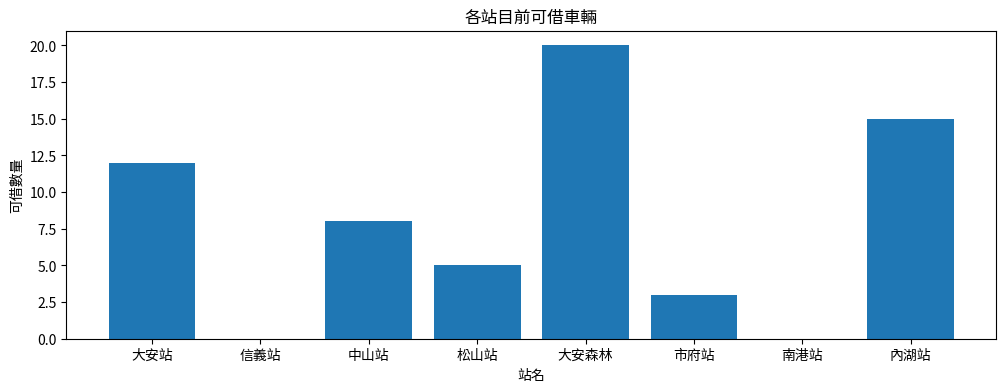

In [11]:
# (1) 長條圖 bar：各站可借車輛
plt.figure(figsize=(12, 4))
plt.bar(df["站名"], df["可借"])
plt.title("各站目前可借車輛")
plt.xlabel("站名")
plt.ylabel("可借數量")
plt.show()

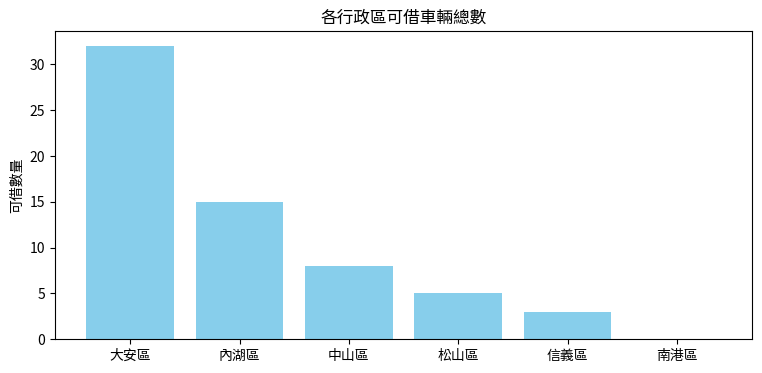

In [12]:
# 結合 pandas：各行政區可借總數，由多到少畫出來
by_area = df.groupby("行政區")["可借"].sum().sort_values(ascending=False)

plt.figure(figsize=(9, 4))
plt.bar(by_area.index, by_area.values, color="skyblue")
plt.title("各行政區可借車輛總數")
plt.ylabel("可借數量")
plt.show()

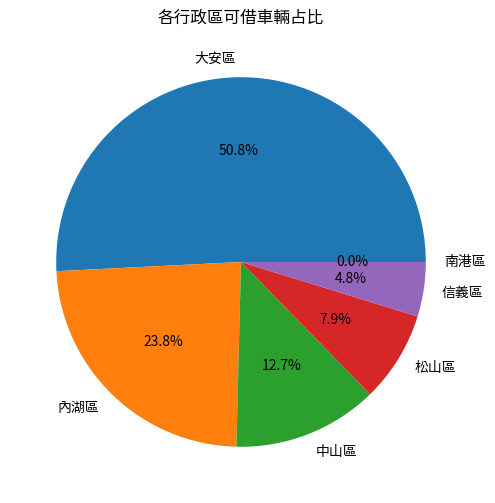

In [13]:
# (2) 圓餅圖 pie：各行政區可借車輛占比
plt.figure(figsize=(6, 6))
plt.pie(by_area.values, labels=by_area.index, autopct="%1.1f%%")
plt.title("各行政區可借車輛占比")
plt.show()

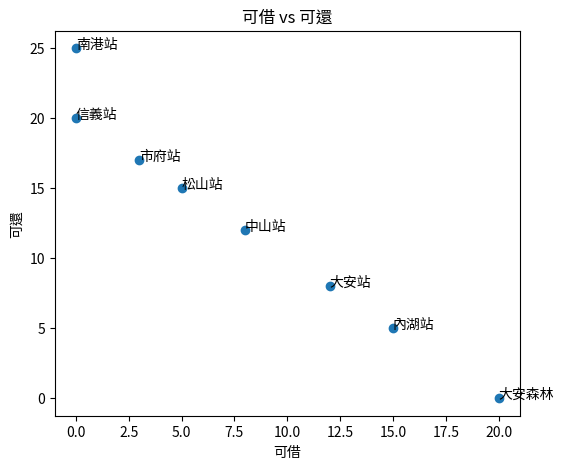

In [14]:
# (3) 散點圖 scatter：看「可借」和「可還」有沒有關係
plt.figure(figsize=(6, 5))
plt.scatter(df["可借"], df["可還"])
plt.title("可借 vs 可還")
plt.xlabel("可借")
plt.ylabel("可還")
# 幫每個點標上站名
for _, row in df.iterrows():
    plt.annotate(row["站名"], (row["可借"], row["可還"]))
plt.show()